# Basic Usage

This notebook demonstrates the basic usage of metalog-jax for fitting metalog distributions.

In [1]:
import tempfile
from pathlib import Path

import jax.numpy as jnp
import numpy as np
from scipy.stats import t

from metalog_jax.base import (
    MetalogBoundedness,
    MetalogFitMethod,
    MetalogInputData,
    MetalogParameters,
    MetalogPlotOptions,
    MetalogRandomVariableParameters,
)
from metalog_jax.metalog import (
    Metalog,
    fit,
)
from metalog_jax.utils import (
    DEFAULT_Y,
    HDRPRNGParameters,
    JaxUniformDistributionParameters,
)

In [2]:
# default quantiles used to fit metalog, overrideable by user
DEFAULT_Y

Array([0.001     , 0.003     , 0.006     , 0.01      , 0.02      ,
       0.03      , 0.04      , 0.05      , 0.06      , 0.07      ,
       0.08      , 0.09      , 0.09999999, 0.11      , 0.12      ,
       0.13      , 0.14      , 0.14999999, 0.16      , 0.17      ,
       0.17999999, 0.19      , 0.19999999, 0.21      , 0.22      ,
       0.22999999, 0.24      , 0.25      , 0.26      , 0.26999998,
       0.28      , 0.29      , 0.29999998, 0.31      , 0.32      ,
       0.32999998, 0.34      , 0.35      , 0.35999998, 0.37      ,
       0.38      , 0.39      , 0.39999998, 0.41      , 0.42      ,
       0.42999998, 0.44      , 0.45      , 0.45999998, 0.47      ,
       0.48      , 0.48999998, 0.5       , 0.51      , 0.52      ,
       0.53      , 0.53999996, 0.55      , 0.56      , 0.57      ,
       0.58      , 0.59      , 0.59999996, 0.61      , 0.62      ,
       0.63      , 0.64      , 0.65      , 0.65999997, 0.66999996,
       0.68      , 0.69      , 0.7       , 0.71      , 0.71999

In [3]:
# input data
dist = t(df=6, loc=50, scale=5)
rvs = jnp.array(dist.rvs(size=1000, random_state=42))
ppf = jnp.array(dist.ppf(DEFAULT_Y))

In [4]:
# init MetalogInputData object from quantiles
# MUST use `from_values` - performs validity checks
data = MetalogInputData.from_values(x=ppf, y=DEFAULT_Y, precomputed_quantiles=True)  # noqa: F841

In [5]:
# init MetalogInputData object from raw data
# MUST use `from_values` - performs validity checks
data_1 = MetalogInputData.from_values(x=rvs, y=DEFAULT_Y, precomputed_quantiles=False)

In [6]:
print(MetalogInputData.__doc__)

Container for input data used to fit metalog distributions.

    This dataclass encapsulates the input data for metalog fitting, supporting two modes:
    (1) fitting from pre-computed quantiles at specified probability levels, or
    (2) fitting from raw sample data where quantiles are computed automatically.

    The mode is controlled by the `precomputed_quantiles` flag, which determines how
    the `x` array should be interpreted and processed during fitting.

    **IMPORTANT**: Instances MUST be created using the `from_values()` classmethod.
    Direct instantiation via `__init__()` is prevented by a `__post_init__` validation
    that raises `TypeError` if the instance was not created through `from_values()`.

    Attributes:
        x: Input data array. The interpretation depends on `precomputed_quantiles`:
            - If `precomputed_quantiles=True`: Array of quantile values
            - If `precomputed_quantiles=False`: Array of raw sample data

        y: Array of probabil

In [7]:
# init MetalogParameters
metalog_params = MetalogParameters(
    boundedness=MetalogBoundedness.UNBOUNDED,
    lower_bound=0,
    upper_bound=1,
    method=MetalogFitMethod.OLS,
    num_terms=5,
)

In [8]:
print(MetalogParameters.__doc__)

Configuration parameters for standard regression-based metalog distributions.

    Extends MetalogParametersBase with regression-specific parameters for fitting
    metalog distributions via regression methods including OLS and Lasso.

    Attributes:
        boundedness: Inherited. Type of domain constraint for the distribution.
            Defined in metalog_jax.base.enums.MetalogBoundedness.
        lower_bound: Inherited. Lower boundary value.
        upper_bound: Inherited. Upper boundary value.
        method: Regression method used for fitting. One of:
            - MetalogFitMethod.OLS: metalog_jax.regression.ols
            - MetalogFitMethod.Lasso: metalog_jax.regression.lasso
        num_terms: Number of terms in the metalog series expansion.

    See Also:
        MetalogParametersBase: Parent class with boundedness and bound attributes.
        metalog_jax.base.enums.MetalogFitMethod: Enumeration of regression methods.
        metalog_jax.metalog.fit: Function that uses Me

In [9]:
# boundedness options
list(MetalogBoundedness.__members__.keys())

['UNBOUNDED', 'STRICTLY_LOWER_BOUND', 'STRICTLY_UPPER_BOUND', 'BOUNDED']

In [10]:
# fit options
list(MetalogFitMethod.__members__.keys())

['OLS', 'Lasso']

In [11]:
# fit metalog, return distribution object
metalog = fit(data_1, metalog_params)

In [12]:
print(fit.__doc__)

Fit a metalog distribution to data using the specified configuration.

    Estimates the metalog distribution coefficients by solving a linear regression
    problem that maps the basis functions (target matrix) to the transformed quantiles.
    The regression method specified in metalog_params determines the fitting approach,
    and optional regression_hyperparams allow fine-tuning of regularization settings.

    This function processes a `MetalogInputData` instance containing validated input
    data (quantiles and probability levels) and fits a metalog distribution according
    to the specified parameters. The data must be created using `MetalogInputData.from_values()`
    which performs comprehensive validation.

    Args:
        data: Validated input data created via `MetalogInputData.from_values()`.
            Contains:
            - x: Quantile values (precomputed or computed from raw samples)
            - y: Probability levels in (0, 1)
            - precomputed_quantiles

In [13]:
# get quantiles from fitted metalog
metalog.ppf(DEFAULT_Y)

Array([29.95720124, 32.93275555, 34.81879152, 36.2188533 , 38.14703942,
       39.30244363, 40.14225617, 40.80945681, 41.3676083 , 41.85055668,
       42.27846637, 42.66432549, 43.01698605, 43.34275495, 43.64628225,
       43.931095  , 44.19993401, 44.4549694 , 44.69795139, 44.93031086,
       45.15323358, 45.36771415, 45.57459486, 45.77459613, 45.96833968,
       46.15636517, 46.33914684, 46.51710131, 46.69059874, 46.85997024,
       47.02551305, 47.18749501, 47.34615984, 47.50173044, 47.65440987,
       47.80438709, 47.9518366 , 48.09692012, 48.23979035, 48.38059019,
       48.51945489, 48.65651264, 48.79188681, 48.92569471, 49.05804937,
       49.18906136, 49.31883854, 49.44748421, 49.57510249, 49.70179578,
       49.82766445, 49.95281037, 50.077335  , 50.20134075, 50.32493127,
       50.44821227, 50.57129174, 50.69428103, 50.81729265, 50.94044617,
       51.06386405, 51.18767504, 51.31201344, 51.43702159, 51.56284711,
       51.68964974, 51.81759775, 51.94687094, 52.07766242, 52.21

In [14]:
print(Metalog.ppf.__doc__)

Compute the percent point function (quantile function) of the distribution.

        The PPF is the inverse of the CDF: for a probability p, ppf(p) returns
        the value x such that P(X <= x) = p.

        Args:
            x: Probability values in (0, 1) at which to evaluate the quantile function.
                Can be a scalar or array.

        Returns:
            chex.Numeric: Quantile values corresponding to the input probabilities.
                Same shape as input.

        Raises:
            ValueError: If x contains values outside (0, 1).
            NotFittedError: If the distribution has not been fitted.
        


In [15]:
# get quantiles from fitted metalog, compatible with rmetalog API
metalog.q(DEFAULT_Y)

Array([29.95720115, 32.93275553, 34.81879153, 36.21885333, 38.14703948,
       39.30244362, 40.14225613, 40.80945687, 41.36760832, 41.85055673,
       42.27846637, 42.66432548, 43.01698604, 43.34275496, 43.64628224,
       43.93109502, 44.19993403, 44.4549694 , 44.69795141, 44.93031089,
       45.15323357, 45.36771415, 45.57459487, 45.77459614, 45.9683397 ,
       46.15636516, 46.33914685, 46.51710131, 46.69059872, 46.85997024,
       47.02551304, 47.18749501, 47.34615984, 47.50173044, 47.65440986,
       47.80438709, 47.9518366 , 48.09692012, 48.23979034, 48.38059019,
       48.51945489, 48.65651265, 48.79188681, 48.92569471, 49.05804937,
       49.18906136, 49.31883854, 49.44748421, 49.57510249, 49.70179578,
       49.82766445, 49.95281037, 50.077335  , 50.20134075, 50.32493127,
       50.44821227, 50.57129174, 50.69428103, 50.81729265, 50.94044617,
       51.06386405, 51.18767504, 51.31201344, 51.43702159, 51.56284711,
       51.68964974, 51.81759775, 51.94687094, 52.07766242, 52.21

In [16]:
# results are identical
ppf_1 = metalog.ppf(DEFAULT_Y)
q = metalog.q(DEFAULT_Y)
np.testing.assert_allclose(ppf_1, q)

In [17]:
# can also get logppf
metalog.logppf(DEFAULT_Y)

Array([3.39976974, 3.49446777, 3.55015723, 3.58957979, 3.64144815,
       3.6712867 , 3.69242955, 3.70891384, 3.72249817, 3.7341051 ,
       3.74427789, 3.7533631 , 3.76159506, 3.76913956, 3.77611811,
       3.78262238, 3.7887233 , 3.79447675, 3.79992767, 3.80511264,
       3.8100619 , 3.81480071, 3.81935043, 3.82372927, 3.82795289,
       3.83203487, 3.83598711, 3.83982002, 3.84354283, 3.8471638 ,
       3.85069029, 3.85412892, 3.85748571, 3.86076614, 3.86397517,
       3.86711742, 3.8701971 , 3.87321814, 3.87618421, 3.8790987 ,
       3.88196485, 3.88478567, 3.88756405, 3.89030271, 3.89300428,
       3.89567127, 3.89830613, 3.90091118, 3.90348874, 3.90604106,
       3.90857034, 3.91107877, 3.91356851, 3.91604173, 3.91850061,
       3.92094731, 3.92338406, 3.9258131 , 3.9282367 , 3.93065723,
       3.93307709, 3.93549878, 3.9379249 , 3.94035818, 3.9428014 ,
       3.94525756, 3.94772982, 3.95022148, 3.95273611, 3.95527749,
       3.95784969, 3.96045706, 3.96310434, 3.96579667, 3.96853

In [18]:
print(Metalog.logppf.__doc__)

Compute the natural logarithm of the percent point function.

        Args:
            x: Probability values in (0, 1) at which to evaluate log(PPF).

        Returns:
            chex.Numeric: Log-quantile values. Same shape as input.
        


In [19]:
# survival function
metalog.sf(ppf_1)

Array([0.999     , 0.997     , 0.994     , 0.99      , 0.98      ,
       0.97      , 0.96000004, 0.95000005, 0.94000006, 0.93000007,
       0.92      , 0.91      , 0.90000004, 0.89000005, 0.88000005,
       0.87000006, 0.8600001 , 0.8500001 , 0.8400001 , 0.8300001 ,
       0.8200001 , 0.8100001 , 0.8000001 , 0.7900001 , 0.7800001 ,
       0.7700001 , 0.7600001 , 0.7500001 , 0.7400001 , 0.73000014,
       0.72000015, 0.71000016, 0.70000017, 0.6900002 , 0.6800002 ,
       0.6700002 , 0.6600002 , 0.6500002 , 0.6400002 , 0.63000023,
       0.62000024, 0.6100002 , 0.6000002 , 0.5900002 , 0.5800002 ,
       0.57000023, 0.56000024, 0.55000025, 0.54000026, 0.5300002 ,
       0.5200002 , 0.5100002 , 0.50000024, 0.49000025, 0.48000026,
       0.47000027, 0.46000028, 0.4500003 , 0.4400003 , 0.4300003 ,
       0.4200003 , 0.41000032, 0.40000033, 0.39000034, 0.38000035,
       0.37000036, 0.3600003 , 0.35000032, 0.34000033, 0.33000034,
       0.32000035, 0.31000036, 0.30000037, 0.29000038, 0.28000

In [20]:
print(Metalog.sf.__doc__)

Compute the survival function (complement of CDF).

        The survival function is S(x) = 1 - F(x) = P(X > x).

        Args:
            x: Quantile values at which to evaluate the survival function.

        Returns:
            chex.Numeric: Survival probabilities in (0, 1). Same shape as input.
        


In [21]:
# inverse survival function
metalog.isf(DEFAULT_Y)

Array([73.95582464, 69.85108314, 67.26032398, 65.35104278, 62.76268264,
       61.25198163, 60.18288371, 59.35575938, 58.68154566, 58.1126676 ,
       57.62068359, 57.18722231, 56.79971684, 56.44919672, 56.12902185,
       55.83414245, 55.56062644, 55.30535036, 55.06579194, 54.83988112,
       54.62590514, 54.42242037, 54.22820418, 54.04220926, 53.8635321 ,
       53.6913887 , 53.52509089, 53.36403285, 53.20767717, 53.05554641,
       52.90721172, 52.76228724, 52.62042529, 52.48130744, 52.34464746,
       52.21018049, 52.07766242, 51.94687094, 51.81759775, 51.68964974,
       51.56284711, 51.43702159, 51.31201415, 51.18767585, 51.06386487,
       50.94044698, 50.81729265, 50.69428103, 50.57129232, 50.44821227,
       50.32493127, 50.20134075, 50.077335  , 49.95281055, 49.82766465,
       49.70179599, 49.57510339, 49.44748421, 49.31883854, 49.18906221,
       49.05804984, 48.92569518, 48.79188729, 48.65651264, 48.51945489,
       48.38059019, 48.23979055, 48.09692014, 47.95183699, 47.80

In [22]:
print(Metalog.isf.__doc__)

Compute the inverse survival function (inverse complementary CDF).

        Returns the value x such that P(X > x) = q, equivalent to ppf(1 - q).

        Args:
            q: Probability values in (0, 1).

        Returns:
            chex.Numeric: Quantile values corresponding to survival probabilities.
        


In [23]:
# get the percentile from an input value
metalog.cdf(ppf_1)

Array([0.001     , 0.003     , 0.006     , 0.01      , 0.01999999,
       0.02999998, 0.03999998, 0.04999997, 0.05999997, 0.06999996,
       0.07999996, 0.08999995, 0.09999995, 0.10999994, 0.11999994,
       0.12999994, 0.13999993, 0.14999992, 0.15999992, 0.16999991,
       0.1799999 , 0.1899999 , 0.1999999 , 0.20999989, 0.21999988,
       0.22999988, 0.23999988, 0.24999987, 0.25999987, 0.26999986,
       0.27999985, 0.28999984, 0.29999983, 0.30999982, 0.31999984,
       0.32999983, 0.33999982, 0.34999982, 0.3599998 , 0.3699998 ,
       0.3799998 , 0.3899998 , 0.3999998 , 0.4099998 , 0.41999978,
       0.42999977, 0.43999976, 0.44999975, 0.45999974, 0.46999976,
       0.47999975, 0.48999974, 0.49999973, 0.50999975, 0.51999974,
       0.52999973, 0.5399997 , 0.5499997 , 0.5599997 , 0.5699997 ,
       0.5799997 , 0.5899997 , 0.59999967, 0.60999966, 0.61999965,
       0.62999964, 0.6399997 , 0.6499997 , 0.65999967, 0.66999966,
       0.67999965, 0.68999964, 0.69999963, 0.7099996 , 0.71999

In [24]:
print(Metalog.cdf.__doc__)

Compute the cumulative distribution function.

        Returns P(X <= q) for the fitted metalog distribution. Uses numerical
        inversion of the quantile function via nearest-neighbor lookup.

        Args:
            q: Quantile values at which to evaluate the CDF. Can be a scalar
                or 1D array.

        Returns:
            chex.Numeric: Probability values in (0, 1). Same shape as input.
        


In [25]:
# to get density of a percentile
metalog.pdf(DEFAULT_Y)

Array([0.0003697 , 0.00110538, 0.00219771, 0.0036314 , 0.00709707,
       0.0103947 , 0.01353201, 0.01651908, 0.0193665 , 0.02208461,
       0.0246832 , 0.02717136, 0.02955746, 0.03184915, 0.03405339,
       0.03617649, 0.03822416, 0.04020155, 0.04211331, 0.04396361,
       0.04575619, 0.04749438, 0.04918117, 0.05081918, 0.05241073,
       0.05395786, 0.05546233, 0.05692562, 0.05834901, 0.05973352,
       0.06107998, 0.06238899, 0.06366098, 0.06489617, 0.06609462,
       0.0672562 , 0.06838061, 0.06946741, 0.07051594, 0.07152547,
       0.07249503, 0.07342356, 0.07430983, 0.07515249, 0.07595002,
       0.07670078, 0.07740302, 0.07805486, 0.07865428, 0.07919917,
       0.07968733, 0.08011645, 0.08048415, 0.08078795, 0.08102536,
       0.08119379, 0.08129068, 0.08131342, 0.0812594 , 0.08112608,
       0.08091092, 0.0806115 , 0.08022545, 0.07975054, 0.07918469,
       0.07852601, 0.0777728 , 0.07692356, 0.07597709, 0.07493246,
       0.07378905, 0.07254657, 0.07120511, 0.0697651 , 0.06822

In [26]:
print(Metalog.pdf.__doc__)

Compute the probability density function of the metalog distribution.

        The PDF is computed as the reciprocal of the derivative of the quantile
        function (PPF), with appropriate transformations for bounded distributions.

        Args:
            x: Probability values in (0, 1) at which to evaluate the PDF.
                Can be a scalar or array.

        Returns:
            chex.Numeric: Probability density values. Same shape as input.

        Raises:
            ValueError: If x contains values outside (0, 1).
            NotFittedError: If the distribution has not been fitted.
            InvalidPDFError: If the PDF contains non-positive values, indicating
                an infeasible metalog fit.
        


In [27]:
# can also generate logpdf
metalog.logpdf(DEFAULT_Y)

Array([-7.90282201, -6.80756844, -6.12033895, -5.61813663, -4.94807395,
       -4.56645915, -4.3026975 , -4.10323936, -3.9442106 , -3.81287423,
       -3.70163238, -3.60559174, -3.52141915, -3.44674456, -3.37982571,
       -3.31934586, -3.26428753, -3.21384968, -3.16739139, -3.12439295,
       -3.08442826, -3.04714385, -3.01224454, -2.97948153, -2.94864385,
       -2.91955183, -2.89205127, -2.86600969, -2.84131292, -2.81786194,
       -2.79557113, -2.77436648, -2.75418346, -2.73496662, -2.71666786,
       -2.69924606, -2.68266591, -2.66689763, -2.65191645, -2.63770173,
       -2.62423729, -2.61151038, -2.59951199, -2.58823602, -2.57767981,
       -2.56784335, -2.55872943, -2.55034339, -2.54269324, -2.53578944,
       -2.52964467, -2.52427405, -2.51969501, -2.51592741, -2.51299309,
       -2.51091645, -2.50972388, -2.50944424, -2.51010872, -2.51175077,
       -2.51440643, -2.51811395, -2.52291453, -2.52885179, -2.53597226,
       -2.54432531, -2.55396357, -2.56494312, -2.57732341, -2.59

In [28]:
print(Metalog.logpdf.__doc__)

Compute the natural logarithm of the probability density function.

        Args:
            x: Probability values in (0, 1) at which to evaluate log(PDF).

        Returns:
            chex.Numeric: Log-density values. Same shape as input.
        


In [29]:
# to generate samples from distribution, we first init a PRNG parameter object
# below is standard jax PRNG
uniform_prng_params = JaxUniformDistributionParameters(seed=42)
uniform_prng_params

JaxUniformDistributionParameters(seed=42)

In [30]:
print(JaxUniformDistributionParameters.__doc__)

Configuration parameters for a JAX uniform distribution.

    Attributes:
        seed: Seed for the psuedorandom number generator.
    


In [31]:
# below is Hubbard Decision Research PRNG
hdr_prng_params = HDRPRNGParameters()
hdr_prng_params

HDRPRNGParameters(trial=1, variable=0, entity=0, time=0, agent=0)

In [32]:
print(HDRPRNGParameters.__doc__)

Structure for Hubbard Decision Research Parameterized PRNG.

    See paper below:

    Douglas W. Hubbard.
    2019.
    A multi-dimensional,
    counter-based psuedo random number generator
    as a standard for Monte Carlo simulations.
    In Proceedings of the Winter Simulation Conference.
    IEEE Press, 3064 - 3073.

    Attributes:
        trial: Seed representing the simulation trial or iteration. Defaults to 1.
        variable: Parameter representing the random variable being sampled. Defaults to 0.
        entity: Parameter representing the entity or object being simulated. Defaults to 0.
        time: Parameter representing the time step in the simulation. Defaults to 0.
        agent: Parameter representing the agent or actor in the simulation. Defaults to 0.
    


In [33]:
# init metalog RV parameters
metalog_rv_params = MetalogRandomVariableParameters(
    prng_params=uniform_prng_params, size=10
)

In [34]:
print(MetalogRandomVariableParameters.__doc__)

Configuration parameters for drawing rvs from fitted metalog distribution.

    Attributes:
        prng_params: Params for the psuedorandom number generator.
        size: The number of random variables to draw. Must be strictly positive.
        max_draws: Maximum number of draws for rejection sampling.
    


In [35]:
# generate samples
metalog.rvs(metalog_rv_params)

Array([43.99698118, 49.25928511, 50.12823078, 54.48041821, 58.67536461,
       44.92803401, 51.19635643, 49.72324526, 47.82517579, 54.10827222],      dtype=float64)

In [36]:
print(Metalog.rvs.__doc__)

Generate random variates from the fitted metalog distribution.

        Samples are generated by drawing uniform random values and applying
        the quantile function (inverse transform sampling).

        Args:
            rv_params: Parameters controlling random variate generation, including
                PRNG configuration (HDR or JAX-based) and sample size.

        Returns:
            chex.Numeric: Random samples from the distribution, shape (size,).

        Raises:
            chex.AssertionError: If size is not positive or exceeds max_draws.
            InvalidPDFError: If the PDF is infeasible (contains non-positive values).
        


In [37]:
# get mean
metalog.mean

Array(50.03155654, dtype=float64)

In [38]:
print(Metalog.mean.__doc__)

Compute the mean (expected value) of the metalog distribution.

        Estimated via Monte Carlo sampling with 20,000 draws.

        Returns:
            chex.Scalar: The estimated mean of the distribution.
        


In [39]:
# get standard deviation
metalog.std

Array(5.67292401, dtype=float64)

In [40]:
print(Metalog.std.__doc__)

Compute the standard deviation of the metalog distribution.

        Estimated via Monte Carlo sampling with 20,000 draws.

        Returns:
            chex.Scalar: The estimated standard deviation of the distribution.
        


In [41]:
# get variance
metalog.var

Array(32.18206683, dtype=float64)

In [42]:
print(Metalog.var.__doc__)

Compute the variance of the metalog distribution.

        Estimated via Monte Carlo sampling with 20,000 draws.

        Returns:
            chex.Scalar: The estimated variance of the distribution.
        


In [43]:
# get median
metalog.median

Array(50.077335, dtype=float64)

In [44]:
print(Metalog.median.__doc__)

Compute the median of the metalog distribution.

        The median is the 50th percentile, computed exactly via ppf(0.5).

        Returns:
            chex.Scalar: The median of the distribution.
        


In [45]:
# get mode
metalog.mode

Array(50.66968091, dtype=float64)

In [46]:
print(Metalog.mode.__doc__)

Compute the mode (most likely value) of the fitted metalog distribution.

        The mode is found by locating the maximum of the PDF over a fine grid
        of probability values.

        Returns:
            chex.Scalar: The mode of the distribution.
        


In [47]:
# plot options
list(MetalogPlotOptions.__members__.keys())

['PDF', 'CDF', 'SF']

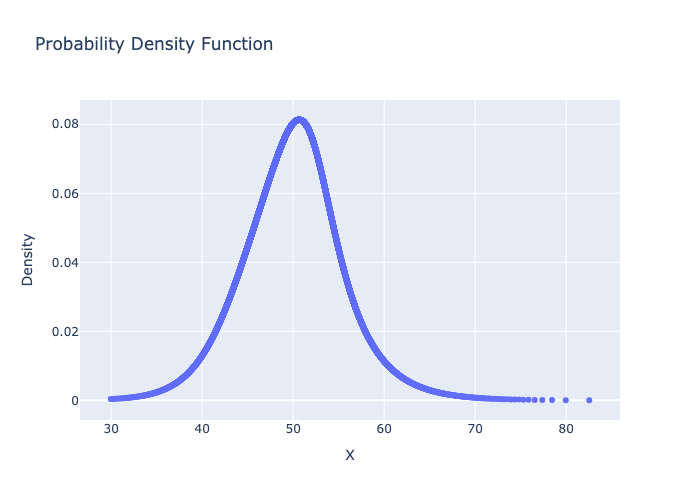

In [48]:
# plot the Probability Density Function
import plotly.io as pio

pio.renderers.default = None  # Disable auto-display
fig = metalog.plot(MetalogPlotOptions.PDF)
fig.write_image("basic_usage_pdf.png")
from IPython.display import Image

Image("basic_usage_pdf.png")

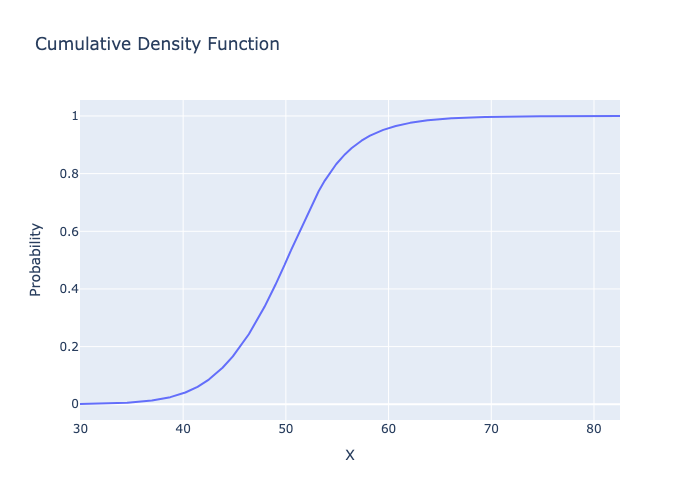

In [49]:
# plot the Cumulative Distribution Function
fig = metalog.plot(MetalogPlotOptions.CDF)
fig.write_image("basic_usage_cdf.png")
Image("basic_usage_cdf.png")

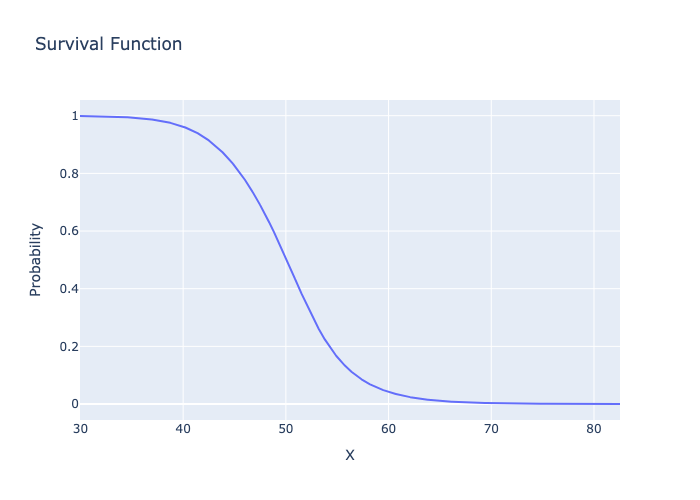

In [50]:
# plot the Survival Function
fig = metalog.plot(MetalogPlotOptions.SF)
fig.write_image("basic_usage_sf.png")
Image("basic_usage_sf.png")

In [51]:
print(Metalog.plot.__doc__)

Visualize the fitted metalog distribution using interactive Plotly plots.

        Creates an interactive Plotly figure showing the selected distribution
        function (PDF, CDF, or survival function).

        Args:
            plot_option: Which function to plot. One of MetalogPlotOptions.PDF,
                MetalogPlotOptions.CDF, or MetalogPlotOptions.SF.

        Returns:
            go.Figure: The Plotly figure object.

        Raises:
            NotFittedError: If the distribution has not been fitted.
        


In [52]:
# save a fitted metalog instance
with tempfile.TemporaryDirectory() as _tmpdir:
    _save_path = Path(_tmpdir) / "test_metalog.json"
    metalog.save(_save_path)
    assert _save_path.exists()

In [53]:
print(Metalog.save.__doc__)

Save the fitted metalog distribution to a JSON file.

        Serializes the distribution coefficients and parameters to JSON format.

        Args:
            path: File path where the JSON file will be written.
        


In [54]:
# load a previously saved metalog
with tempfile.TemporaryDirectory() as _tmpdir:
    _save_path = Path(_tmpdir) / "test_metalog.json"
    metalog.save(_save_path)
    loaded_metalog = Metalog.load(_save_path)
    np.testing.assert_array_almost_equal(
        np.array(loaded_metalog.a), np.array(metalog.a)
    )

In [55]:
print(Metalog.load.__doc__)

Load a fitted metalog distribution from a JSON file.

        Args:
            path: File path to the JSON file containing the serialized distribution.

        Returns:
            T_MetalogBase: A new instance of the metalog class with loaded
                coefficients and parameters.
        
